In [20]:
import shap
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

In [21]:
#carregando o dataset e dividindo em treino e teste
data = load_breast_cancer()
X, y = data.data, data.target

print(list(data.target_names))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

['malignant', 'benign']


In [22]:
#criando e treinando um modelo de support vector machine

clf = LinearSVC()
clf.fit(X_train, y_train)

LinearSVC()

In [23]:
clf.score(X_test, y_test)

0.9210526315789473

In [24]:
clf.predict([X_test[0]])

array([1])

In [25]:
#utilizando o shap apra explicar as previsões
explainer = shap.KernelExplainer(clf.predict, shap.kmeans(X_train, 10))
shap_values = explainer.shap_values(X_test)

  0%|          | 0/114 [00:00<?, ?it/s]

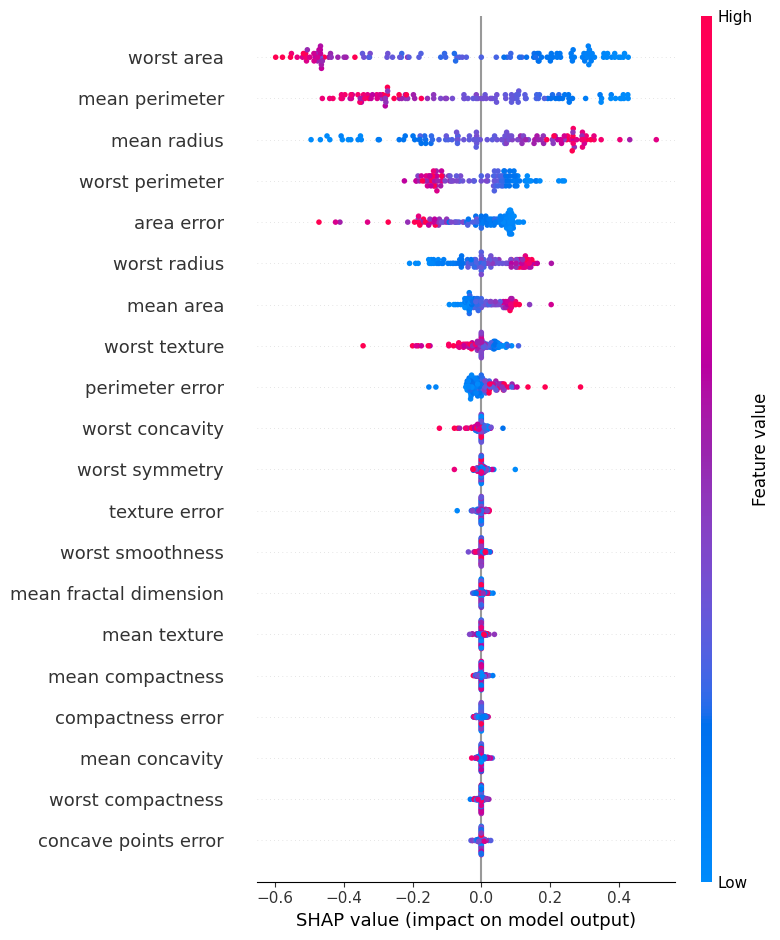

In [26]:
#plotando o gráfico da explicação
shap.summary_plot(shap_values, X_test, feature_names=data['feature_names'])

In [27]:
#visualizando outra forma de gráfico

shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test[0], feature_names=data['feature_names'])

In [28]:
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)
feature_names = data['feature_names']
feature_importance = zip(feature_names, mean_abs_shap_values)

In [29]:
#obtendo os valores de importância para cada característica

sorted_feature_importance = sorted(feature_importance, key= lambda x:x[1], reverse=True)
sorted_feature_importance

[('worst area', 0.30711187077953894),
 ('mean perimeter', 0.22437594948950026),
 ('mean radius', 0.19563587563632265),
 ('worst perimeter', 0.10309851037598808),
 ('area error', 0.09137385952922418),
 ('worst radius', 0.08174766871469197),
 ('mean area', 0.045446871978031406),
 ('worst texture', 0.040668068971151966),
 ('perimeter error', 0.03677898796265583),
 ('worst concavity', 0.012972779979796976),
 ('worst symmetry', 0.00901702283328271),
 ('texture error', 0.007613031102997039),
 ('worst smoothness', 0.00627418825432877),
 ('mean fractal dimension', 0.006272792582155481),
 ('mean texture', 0.006188709585825628),
 ('mean compactness', 0.006098835043168068),
 ('compactness error', 0.006022714113278671),
 ('mean concavity', 0.0059934371652316885),
 ('worst compactness', 0.005979910505585147),
 ('concave points error', 0.005489554413403704),
 ('concavity error', 0.005480397916226171),
 ('radius error', 0.00545856374647709),
 ('worst concave points', 0.005422646357591437),
 ('mean co